In [1]:
"""
Interactive t-SNE Visualization for MRS Data Augmentation
"""

'\nInteractive t-SNE Visualization for MRS Data Augmentation\n'

In [2]:
import os
import sys
sys.path.append(os.path.abspath(os.getcwd() + '/..'))

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np

from fsl_mrs.utils import misc

from matplotlib.gridspec import GridSpec
from matplotlib.widgets import CheckButtons, Button, RadioButtons

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

from augmentrum import Augmentrum

/Users/me/mamba/envs/mine/lib/python3.10/site-packages/hlsvdpropy/__init__.py:21: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
# Helper functions for data loading
def load_cows_data_manually(data_dir, location='PARIETAL', water_sup='VAPOR'):
    """
    Manually load COWS data from Twix files.

    Args:
        data_dir: Path to COWS data directory (e.g., '../data/openneuro_ds006812/')
        location: Brain region - 'PARIETAL' or 'OCCIPITAL'
        water_sup: Water suppression - 'VAPOR' or 'MEGA'

    Returns:
        data, water: Lists of NIFTI_MRS objects
    """
    from augmentrum.dataset.cows import COWSDataModule

    print(f"Loading COWS data from: {data_dir}")
    print(f"  Location: {location}")
    print(f"  Water suppression: {water_sup}")

    # Use the COWSDataModule to load raw data
    loader = COWSDataModule(data_dir=data_dir, location=location, water_sup=water_sup)
    data, water, mm, mm_water, names = loader.load_twix()

    print(f"✓ Loaded {len(data)} subjects")
    return data, water

# Helper functions for spectrum analysis
def find_ppm_indices(ppm_axis, ppm_min, ppm_max):
    """Find indices corresponding to a PPM range."""
    return np.where((ppm_axis >= ppm_min) & (ppm_axis <= ppm_max))[0]


def baseline_correct(specs, baseline_inds):
    """Apply baseline correction using specified indices."""
    corrected = []
    for spec in specs:
        baseline_val = np.mean(np.real(spec[baseline_inds]))
        corrected.append(spec - baseline_val)
    return np.array(corrected)


def normalize_spectra(specs):
    """Normalize spectra to max absolute value."""
    return specs / np.max(np.abs(specs), axis=1, keepdims=True)


def concat_real_imag_and_select_range(specs, pca_inds):
    """Concatenate real and imaginary parts and select PPM range."""
    len_half = specs.shape[1]
    specs_concat = np.concatenate([np.real(specs), np.imag(specs)], axis=1)
    real_inds = np.array(pca_inds)
    imag_inds = np.array(pca_inds) + len_half
    return specs_concat[:, np.concatenate([real_inds, imag_inds])]

In [4]:
# ================================================================================
# Load Raw COWS Data
# ================================================================================
print("="*80)
print("LOADING RAW COWS DATA")
print("="*80)

# Load COWS data manually
data_dir = '../data/openneuro_ds006812/'
data, water = load_cows_data_manually(
    data_dir=data_dir,
    location='PARIETAL',
    water_sup='VAPOR'
)

print(f"✓ Loaded {len(data)} subjects")
print("="*80)

LOADING RAW COWS DATA
Loading COWS data from: ../data/openneuro_ds006812/
  Location: PARIETAL
  Water suppression: VAPOR


read data:   0%|          | 0/64 [00:00<?, ?it/s]

read data:   0%|          | 0/64 [00:00<?, ?it/s]

read data:   0%|          | 0/64 [00:00<?, ?it/s]

read data:   0%|          | 0/64 [00:00<?, ?it/s]

...

read data:   0%|          | 0/128 [00:00<?, ?it/s]

read data:   0%|          | 0/64 [00:00<?, ?it/s]

read data:   0%|          | 0/128 [00:00<?, ?it/s]

read data:   0%|          | 0/64 [00:00<?, ?it/s]

✓ Loaded 10 subjects
✓ Loaded 10 subjects


In [5]:
# ================================================================================
# Create Unaugmented Dataset (deterministic coil/average sampling)
# ================================================================================
print("\n" + "="*80)
print("CREATING UNAUGMENTED AUGMENTRUM (Deterministic Sampling)")
print("="*80)

# Create Augmentrum with deterministic sampling (take all coils/averages)
# This gives us the baseline "unaugmented" data
unaugmented = Augmentrum(
    data=data,
    water=water,

    # Pipeline: just coil sampling (deterministic) + processing
    pipeline=['coil_sampling', 'processing'],

    # === Sampling: Take ALL coils and averages (deterministic) ===
    n_coils=(None, None),        # Take all available coils
    n_averages=(None, None),     # Take all available averages
    mode='deterministic',         # Deterministic mode (no randomness)

    # === Processing Parameters ===
    coil_method='fsl-mrs',       # Coil combination method
    conj=False,                  # Whether to conjugate FIDs

    # === General Settings ===
    backend='numpy',             # Use numpy backend
    volatile=True,               # Fast mode - skip metadata updates
    batch_size=64,               # Batch size for dataloader
    val_frac=0.0,                # No validation split
    test_frac=0.0,               # No test split
)

print(f"✓ Unaugmented Augmentrum created")
print(f"  Pipeline: {' → '.join(['coil_sampling', 'processing'])}")
print(f"  Mode: deterministic (all coils/averages)")
print(f"  Batch size: {unaugmented.batch_size}")

# Get unaugmented batch
x, x_ref = next(iter(unaugmented.train_dataloader(framework='numpy')))

# Squeeze to remove singleton dimensions (x, y, z)
x = np.squeeze(x)
if x_ref is not None:
    x_ref = np.squeeze(x_ref)

print(f"\n✓ Unaugmented data loaded:")
print(f"  Type: {type(x)}")
print(f"  Shape: {x.shape}")
print(f"  ({x.shape[0]} spectra, {x.shape[1]} points)")
print("="*80)


CREATING UNAUGMENTED AUGMENTRUM (Deterministic Sampling)
✓ Unaugmented Augmentrum created
  Pipeline: coil_sampling → processing
  Mode: deterministic (all coils/averages)
  Batch size: 64


/Users/me/Desktop/Augmentrum/augmentrum/core/pipeline.py:82: UserWarning: Step 1 (NIfTI_RawProcessor) does not support backend numpy. Converting to nifti_list. Supported backends: ['nifti_list']
  warnings.warn(
/Users/me/mamba/envs/mine/lib/python3.10/site-packages/fsl_mrs/utils/preproc/combine.py:48: UserWarning: You may not have enough samples to accurately estimate the noise covariance, 10^5 samples recommended.
  warnings.warn(
/Users/me/mamba/envs/mine/lib/python3.10/site-packages/fsl_mrs/utils/preproc/combine.py:79: RuntimeWarning: divide by zero encountered in matmul
  W = V @ np.diag(1 / np.sqrt(D))
/Users/me/mamba/envs/mine/lib/python3.10/site-packages/fsl_mrs/utils/preproc/combine.py:79: RuntimeWarning: overflow encountered in matmul
  W = V @ np.diag(1 / np.sqrt(D))
/Users/me/mamba/envs/mine/lib/python3.10/site-packages/fsl_mrs/utils/preproc/combine.py:79: RuntimeWarning: invalid value encountered in matmul
  W = V @ np.diag(1 / np.sqrt(D))
/Users/me/mamba/envs/mine/lib/pyt


✓ Unaugmented data loaded:
  Type: <class 'numpy.ndarray'>
  Shape: (10, 4096)
  (10 spectra, 4096 points)


In [6]:
# ================================================================================
# Create Augmented Dataset (random coil/average sampling)
# ================================================================================
print("\n" + "="*80)
print("CREATING AUGMENTED AUGMENTRUM (Random Sampling)")
print("="*80)

# Define augmentation pipeline
# Available modules: 'coil_sampling', 'processing', 'noise', 'line_broadening',
#                   'baseline', 'phase', 'frequency_shift', 'residual_water', etc.
augmentation_pipeline = [
    'coil_sampling',      # Randomly sample coils and averages
    'processing',         # Process raw data (coil combination, etc.)
    # Uncomment to add more augmentations:
    # 'noise',            # Add Gaussian noise
    # 'line_broadening',  # Add line broadening
    # 'baseline',         # Add baseline distortions
]

# Create Augmentrum instance with random sampling
# This creates augmented versions by randomly sampling coils/averages
augmented = Augmentrum(
    data=data,                    # Same raw data as unaugmented
    water=water,

    # Pipeline: coil sampling (random) + processing + optional augmentations
    pipeline=augmentation_pipeline,

    # === Coil/Average Sampling: Random sampling ===
    n_coils=(1, None),           # Sample 1 to all available coils randomly
    n_averages=(1, None),        # Sample 1 to all available averages randomly
    mode='random',               # Random sampling mode

    # === Processing Parameters ===
    coil_method='fsl-mrs',       # Coil combination method
    conj=False,                  # Whether to conjugate FIDs after processing

    # === Noise Parameters (if 'noise' in pipeline) ===
    # sigma_frac=0.02,           # Add 2% noise relative to signal

    # === Line Broadening Parameters (if 'line_broadening' in pipeline) ===
    # lb_hz=(0, 5),              # Lorentzian broadening: 0-5 Hz
    # gb_hz=(0, 3),              # Gaussian broadening: 0-3 Hz

    # === Baseline Parameters (if 'baseline' in pipeline) ===
    # baseline_mode='random_walk',  # 'random_walk', 'bspline', or 'polynomial'
    # baseline_frac=0.10,        # 10% of signal amplitude

    # === General Settings ===
    backend='numpy',             # Use numpy backend
    volatile=True,               # Fast mode - skip metadata updates
    batch_size=256,               # Generate augmented spectra
    val_frac=0.0,                # No validation split
    test_frac=0.0,               # No test split
)

print(f"✓ Augmented Augmentrum created")
print(f"  Pipeline: {' → '.join(augmentation_pipeline)}")
print(f"  Mode: random (random coils/averages)")
print(f"  Batch size: {augmented.batch_size}")

# Generate augmented batch
x_aug, x_ref_aug = next(iter(augmented.train_dataloader(framework='numpy')))

# Squeeze to remove singleton dimensions (x, y, z)
x_aug = np.squeeze(x_aug)
if x_ref_aug is not None:
    x_ref_aug = np.squeeze(x_ref_aug)

print(f"\n✓ Augmented data generated:")
print(f"  Type: {type(x_aug)}")
print(f"  Shape: {x_aug.shape}")
print(f"  ({x_aug.shape[0]} spectra, {x_aug.shape[1]} points)")
print("="*80)


CREATING AUGMENTED AUGMENTRUM (Random Sampling)
✓ Augmented Augmentrum created
  Pipeline: coil_sampling → processing
  Mode: random (random coils/averages)
  Batch size: 256

✓ Augmented data generated:
  Type: <class 'numpy.ndarray'>
  Shape: (256, 4096)
  (256 spectra, 4096 points)


In [7]:
# ================================================================================
# Configure Visualization Parameters
# ================================================================================
# PPM ranges for analysis
baseline_ppm_range = (9.5, 10.0)  # Baseline correction range
pca_ppm_range = (0.5, 4.5)        # Feature extraction range (metabolite region)

# t-SNE perplexities to compare
perplexities = [5, 10, 15, 20, 25]

# Generate spectrum labels
unaugmented_labels = [f"Unaugmented_{i}" for i in range(x.shape[0])]
augmented_labels = [f"Augmented_{i}" for i in range(x_aug.shape[0])]

# Calculate PPM axis (assuming COWS parameters)
axes = misc.calculateAxes(8000, 123.259299, 4096, 4.65)
ppm_axis = axes['ppmshift']

print(f"\nVisualization Parameters:")
print(f"  Baseline correction: {baseline_ppm_range} ppm")
print(f"  Feature extraction: {pca_ppm_range} ppm")
print(f"  Perplexities: {perplexities}")
print(f"  Total spectra: {x.shape[0]} unaugmented + {x_aug.shape[0]} augmented = {x.shape[0] + x_aug.shape[0]}")


Visualization Parameters:
  Baseline correction: (9.5, 10.0) ppm
  Feature extraction: (0.5, 4.5) ppm
  Perplexities: [5, 10, 15, 20, 25]
  Total spectra: 10 unaugmented + 256 augmented = 266


In [8]:
# ================================================================================
# Process Spectra (FFT, Baseline Correction, Normalization)
# ================================================================================
print("\n" + "="*80)
print("PROCESSING SPECTRA")
print("="*80)

# Convert FIDs to spectra via FFT
unaugmented_spectra_raw = np.fft.fftshift(np.fft.fft(x, axis=1))
augmented_spectra_raw = np.fft.fftshift(np.fft.fft(x_aug, axis=1))

print(f"✓ Converted FIDs to spectra via FFT")

# Baseline correction
baseline_indices = find_ppm_indices(ppm_axis, *baseline_ppm_range)
unaugmented_spectra_bc = baseline_correct(unaugmented_spectra_raw, baseline_indices)
augmented_spectra_bc = baseline_correct(augmented_spectra_raw, baseline_indices)

print(f"✓ Applied baseline correction ({baseline_ppm_range[0]}-{baseline_ppm_range[1]} ppm)")

# Normalization
unaugmented_spectra_norm = normalize_spectra(unaugmented_spectra_bc)
augmented_spectra_norm = normalize_spectra(augmented_spectra_bc)

print(f"✓ Normalized spectra")
print("="*80)


PROCESSING SPECTRA
✓ Converted FIDs to spectra via FFT
✓ Applied baseline correction (9.5-10.0 ppm)
✓ Normalized spectra


In [9]:
# ================================================================================
# Feature Extraction (Real + Imaginary, Selected PPM Range)
# ================================================================================
print("\n" + "="*80)
print("EXTRACTING FEATURES FOR t-SNE")
print("="*80)

pca_indices = find_ppm_indices(ppm_axis, *pca_ppm_range)

unaugmented_features = concat_real_imag_and_select_range(unaugmented_spectra_norm, pca_indices)
augmented_features = concat_real_imag_and_select_range(augmented_spectra_norm, pca_indices)

print(f"✓ Extracted features from {pca_ppm_range[0]}-{pca_ppm_range[1]} ppm")
print(f"  Unaugmented features: {unaugmented_features.shape}")
print(f"  Augmented features: {augmented_features.shape}")

# Combine all features for t-SNE analysis
all_features = np.vstack([unaugmented_features, augmented_features])
all_features_real = all_features[:, :all_features.shape[1] // 2]  # Use only real part for t-SNE

print(f"✓ Combined features: {all_features.shape}")
print(f"  Using real part only for t-SNE: {all_features_real.shape}")

# Create labels for visualization
group_labels = np.array(['Unaugmented'] * len(unaugmented_features) + ['Augmented'] * len(augmented_features))
spectrum_labels = np.array(unaugmented_labels + augmented_labels)

print(f"✓ Created labels: {np.unique(group_labels, return_counts=True)}")
print("="*80)


EXTRACTING FEATURES FOR t-SNE
✓ Extracted features from 0.5-4.5 ppm
  Unaugmented features: (10, 506)
  Augmented features: (256, 506)
✓ Combined features: (266, 506)
  Using real part only for t-SNE: (266, 253)
✓ Created labels: (array(['Augmented', 'Unaugmented'], dtype='<U11'), array([256,  10]))


In [10]:
# ================================================================================
# Dimensionality Reduction: PCA + t-SNE
# ================================================================================
print("\n" + "="*80)
print("RUNNING PCA AND t-SNE")
print("="*80)

# Standardize features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(all_features_real)
print(f"✓ Standardized features")

# PCA for dimensionality reduction (retain 95% variance)
pca = PCA(n_components=0.95)
pca_features = pca.fit_transform(scaled_features)
print(f"✓ PCA reduced dimensions: {all_features_real.shape[1]} → {pca_features.shape[1]}")
print(f"  Explained variance: {pca.explained_variance_ratio_.sum():.2%}")

# Run t-SNE with multiple perplexities
from tqdm import tqdm

tsne_results = {}
print(f"\n✓ Running t-SNE with perplexities: {perplexities}")

for perplexity in tqdm(perplexities, desc="t-SNE"):
    tsne = TSNE(n_components=2, perplexity=perplexity, init='random', random_state=42, max_iter=1000)
    tsne_coords = tsne.fit_transform(pca_features)
    tsne_results[perplexity] = tsne_coords

print(f"✓ Completed t-SNE for {len(perplexities)} perplexity values")
print("="*80)


RUNNING PCA AND t-SNE
✓ Standardized features
✓ PCA reduced dimensions: 253 → 64
  Explained variance: 95.08%

✓ Running t-SNE with perplexities: [5, 10, 15, 20, 25]


t-SNE: 100%|██████████████████████████████████████████████████████████| 5/5 [00:06<00:00,  1.32s/it]

✓ Completed t-SNE for 5 perplexity values


In [11]:
# ================================================================================
# Interactive Visualization Setup
# ================================================================================
print("\n" + "="*80)
print("SETTING UP INTERACTIVE VISUALIZATION")
print("="*80)

%matplotlib widget

# Ensure we have all needed imports for interactive plotting
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.widgets import CheckButtons, Button, RadioButtons
import matplotlib.cm as cm

print("✓ Interactive plotting enabled")
print("="*80)


SETTING UP INTERACTIVE VISUALIZATION
✓ Interactive plotting enabled


/var/folders/3m/ry9cxhhs3g9_p48nkvk2xpjc0000gn/T/ipykernel_54791/1370007396.py:102: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_spec.legend(fontsize=12, loc='upper right', frameon=True)


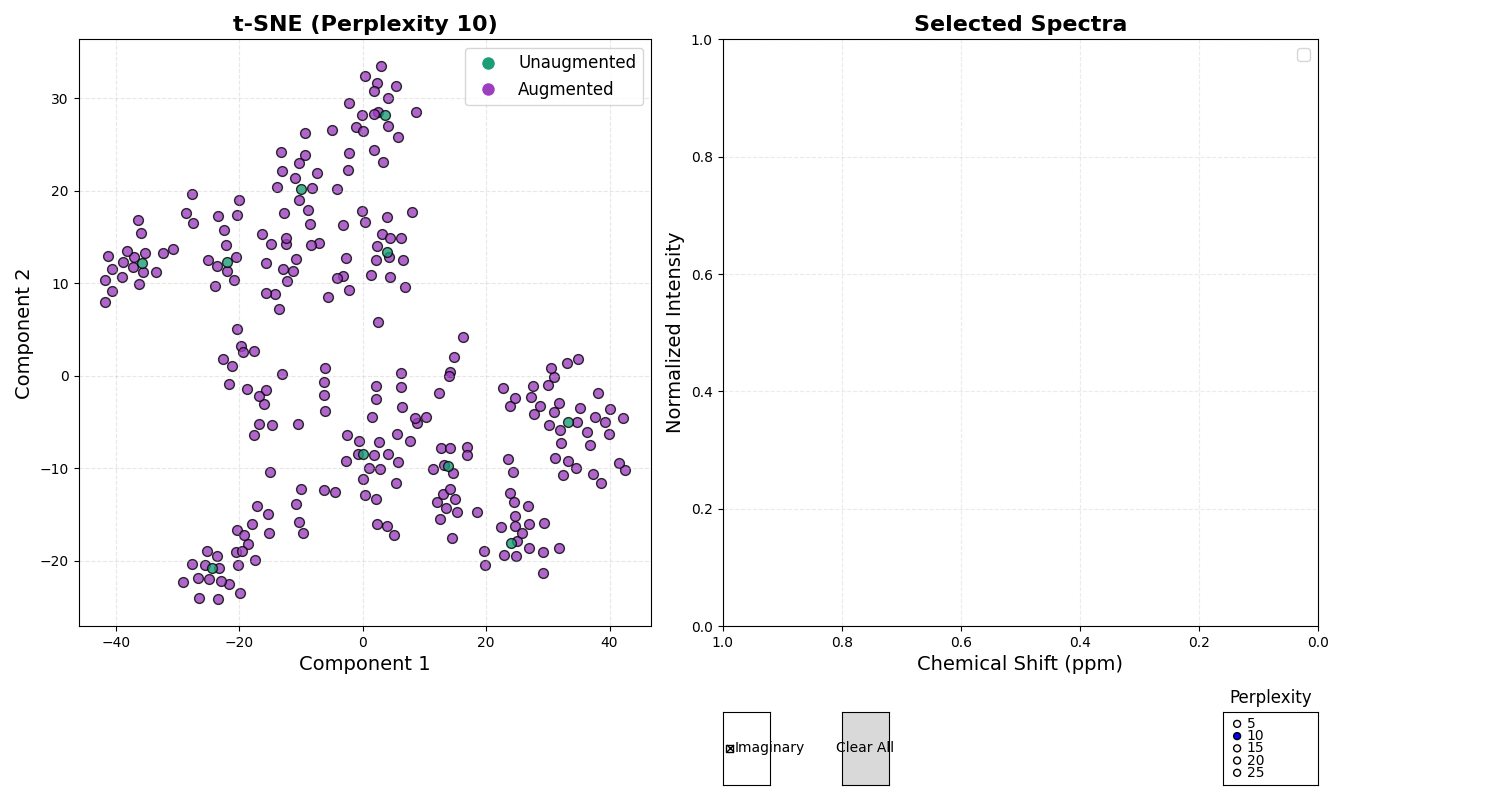

In [13]:
# ================================================================================
# Create Interactive Figure
# ================================================================================

# === Color scheme aligned with colormaps ===
selection_colors = {
    'Unaugmented': '#1b9e77',       # green (cm.Greens)
    'Augmented': '#9c3fbf',         # purple (cm.Purples)
    'highlight_unaugmented': '#66c2a5', # light green
    'highlight_augmented': '#d8b4f7',   # light purple
}

# === Setup combined figure with GridSpec ===
fig = plt.figure(figsize=(15, 8))
gs = GridSpec(2, 6, height_ratios=[8, 1], width_ratios=[6, 0.5, 0.5, 2, 1, 1])

# t-SNE axes
ax_tsne = fig.add_subplot(gs[0, 0])

# Spectrum axes
ax_spec = fig.add_subplot(gs[0, 1:5])

# === Initial t-SNE data ===
current_perplexity = perplexities[1]
tsne_coords = tsne_results[current_perplexity]

# === t-SNE scatter (Unaugmented on top) ===
color_map = {'Unaugmented': selection_colors['Unaugmented'], 'Augmented': selection_colors['Augmented']}
unaugmented_idx = [i for i, g in enumerate(group_labels) if g == 'Unaugmented']
augmented_idx = [i for i, g in enumerate(group_labels) if g == 'Augmented']

# Plot Augmented (behind)
sc_aug = ax_tsne.scatter(tsne_coords[augmented_idx, 0], tsne_coords[augmented_idx, 1],
                         c=color_map['Augmented'], alpha=0.8, s=50,
                         edgecolors='black', label='Augmented', zorder=1)

# Plot Unaugmented (on top)
sc_unaug = ax_tsne.scatter(tsne_coords[unaugmented_idx, 0], tsne_coords[unaugmented_idx, 1],
                           c=color_map['Unaugmented'], alpha=0.8, s=50,
                           edgecolors='black', label='Unaugmented', zorder=2)

ax_tsne.set_title(f't-SNE (Perplexity {current_perplexity})', fontsize=16, weight='bold')
ax_tsne.set_xlabel('Component 1', fontsize=14)
ax_tsne.set_ylabel('Component 2', fontsize=14)
ax_tsne.grid(True, linestyle='--', alpha=0.3)

legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='Unaugmented',
               markerfacecolor=selection_colors['Unaugmented'], markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Augmented',
               markerfacecolor=selection_colors['Augmented'], markersize=10),
]
ax_tsne.legend(handles=legend_elements, loc='upper right', fontsize=12)

highlight_marker = ax_tsne.scatter([], [], facecolors='none', edgecolors='black', s=120, linewidths=2, zorder=3)

# === Selected spectra ===
selected_spectra = []
imaginary_visible = [True]

def update_spectrum_plot():
    ax_spec.clear()
    # Separate selected indices
    unaugmented_indices = [idx for idx in selected_spectra if group_labels[idx] == 'Unaugmented']
    augmented_indices = [idx for idx in selected_spectra if group_labels[idx] == 'Augmented']

    # Colormaps
    unaugmented_cmap = cm.Greens
    augmented_cmap = cm.Purples

    # Colors for lines
    unaugmented_colors = [unaugmented_cmap(0.8) if i==0 else unaugmented_cmap(0.3 + 0.5*i/max(1,len(unaugmented_indices)-1)) for i in range(len(unaugmented_indices))]
    augmented_colors = [augmented_cmap(0.5 + 0.5*i/max(1,len(augmented_indices)-1)) for i in range(len(augmented_indices))]

    # Plot Unaugmented spectra
    for i, idx in enumerate(unaugmented_indices):
        spectrum = all_features[idx]
        mid = len(spectrum)//2
        real, imag = spectrum[:mid], spectrum[mid:]
        ppm = ppm_axis[pca_indices]

        ax_spec.plot(ppm, real, color=unaugmented_colors[i],
                     linewidth=2.5 if i==0 else 1.5, alpha=0.9, label=spectrum_labels[idx])
        if imaginary_visible[0]:
            ax_spec.plot(ppm, imag, '--', color=unaugmented_colors[i], linewidth=1.5, alpha=0.7)

    # Plot Augmented spectra
    for i, idx in enumerate(augmented_indices):
        spectrum = all_features[idx]
        mid = len(spectrum)//2
        real, imag = spectrum[:mid], spectrum[mid:]
        ppm = ppm_axis[pca_indices]

        ax_spec.plot(ppm, real, color=augmented_colors[i], linewidth=1.5, alpha=0.7, label=spectrum_labels[idx])
        if imaginary_visible[0]:
            ax_spec.plot(ppm, imag, '--', color=augmented_colors[i], linewidth=1.2, alpha=0.5)

    # Visual tweaks
    ax_spec.set_title("Selected Spectra", fontsize=16, weight='bold')
    ax_spec.set_xlabel("Chemical Shift (ppm)", fontsize=14)
    ax_spec.set_ylabel("Normalized Intensity", fontsize=14)
    ax_spec.legend(fontsize=12, loc='upper right', frameon=True)
    ax_spec.grid(True, linestyle='--', alpha=0.25)
    ax_spec.invert_xaxis()
    fig.canvas.draw_idle()

    # Update t-SNE highlight markers
    if selected_spectra:
        coords = tsne_coords[selected_spectra]
        highlight_colors = [selection_colors['highlight_unaugmented'] if group_labels[idx]=='Unaugmented' else selection_colors['highlight_augmented'] for idx in selected_spectra]
        highlight_marker.set_offsets(coords)
        highlight_marker.set_facecolors(highlight_colors)
        highlight_marker.set_edgecolors('black')
    else:
        highlight_marker.set_offsets(np.empty((0,2)))
        highlight_marker.set_facecolors([])
        highlight_marker.set_edgecolors([])

# === Interaction functions ===
def toggle_imaginary(label):
    imaginary_visible[0] = not imaginary_visible[0]
    update_spectrum_plot()

def clear_selection(event):
    selected_spectra.clear()
    update_spectrum_plot()

def on_tsne_click(event):
    if event.inaxes != ax_tsne: return
    dist = np.linalg.norm(tsne_coords - [event.xdata, event.ydata], axis=1)
    idx = np.argmin(dist)
    if idx in selected_spectra:
        selected_spectra.remove(idx)
    elif len(selected_spectra) < 10:
        selected_spectra.append(idx)
    else:
        print("Maximum of 10 spectra.")
    update_spectrum_plot()

def update_tsne_plot(label):
    global tsne_coords, current_perplexity
    current_perplexity = int(label)
    tsne_coords = tsne_results[current_perplexity]

    # Update both scatters
    sc_aug.set_offsets(tsne_coords[augmented_idx])
    sc_unaug.set_offsets(tsne_coords[unaugmented_idx])
    ax_tsne.set_title(f't-SNE (Perplexity {current_perplexity})', fontsize=16, weight='bold')

    # Padding
    pad = 0.05
    x_min, x_max = tsne_coords[:,0].min(), tsne_coords[:,0].max()
    y_min, y_max = tsne_coords[:,1].min(), tsne_coords[:,1].max()
    ax_tsne.set_xlim(x_min - (x_max-x_min)*pad, x_max + (x_max-x_min)*pad)
    ax_tsne.set_ylim(y_min - (y_max-y_min)*pad, y_max + (y_max-y_min)*pad)

    update_spectrum_plot()

# === Controls ===
check_ax = fig.add_subplot(gs[1,1])
imaginary_checkbox = CheckButtons(check_ax, ['Imaginary'], [True])
imaginary_checkbox.on_clicked(toggle_imaginary)

clear_ax = fig.add_subplot(gs[1,2])
clear_btn = Button(clear_ax, 'Clear All')
clear_btn.on_clicked(clear_selection)

radio_ax = fig.add_subplot(gs[1,4])
radio = RadioButtons(radio_ax, [str(p) for p in perplexities])
radio.on_clicked(update_tsne_plot)
radio.set_active(1)
radio_ax.set_title("Perplexity", fontsize=12)

fig.canvas.mpl_connect('button_press_event', on_tsne_click)
fig.tight_layout()
plt.show()
